# **Quantum Random Walk**

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from BoredQiskit import FastQiskit as fq

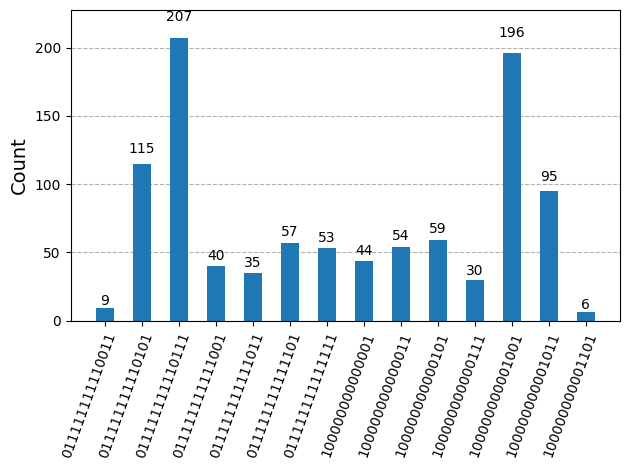

In [5]:
def increment_operator(qubits: int):
    qc = QuantumCircuit(qubits)
    for i in range(qubits-1, 0, -1):
        ctrls = list(range(0,i))
        qc.mcx(ctrls, i)
    qc.x(0)
    return qc.to_gate(label="+")


def decrement_operator(qubits: int):
    qc = QuantumCircuit(qubits)
    for i in range(qubits-1, 0, -1):
        ctrls = list(range(0,i))
        qc.mcx(ctrls, i, ctrl_state='0'*len(ctrls))
    qc.x(0)
    return qc.to_gate(label="-")


def fair_coin():
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.s(0)
    return qc.to_gate(label='fair coin')


def unbiased_quantum_walk(steps: int, qubits: int, centered: bool=True, symmetrical: bool=True):
    qr = QuantumRegister(qubits, 'x')
    qa = QuantumRegister(1, 'coin')
    c = ClassicalRegister(qubits, 'c')
    qc = QuantumCircuit(qr,qa,c)

    if symmetrical:
        qc = qc.compose(fair_coin(), qa)

    if centered: 
        qc.x(qr[qubits-1])

    for _ in range(steps):
        qc.h(qa)
        qc = qc.compose(increment_operator(qubits).control(1), [qa, *qr])
        qc = qc.compose(decrement_operator(qubits).control(1, ctrl_state='0'), [qa, *qr])

    qc.measure(qr, c)

    return qc


qc = unbiased_quantum_walk(15,15, True, True)
shots = 1000
counts = fq.run(qc, shots)
plot_histogram(counts)

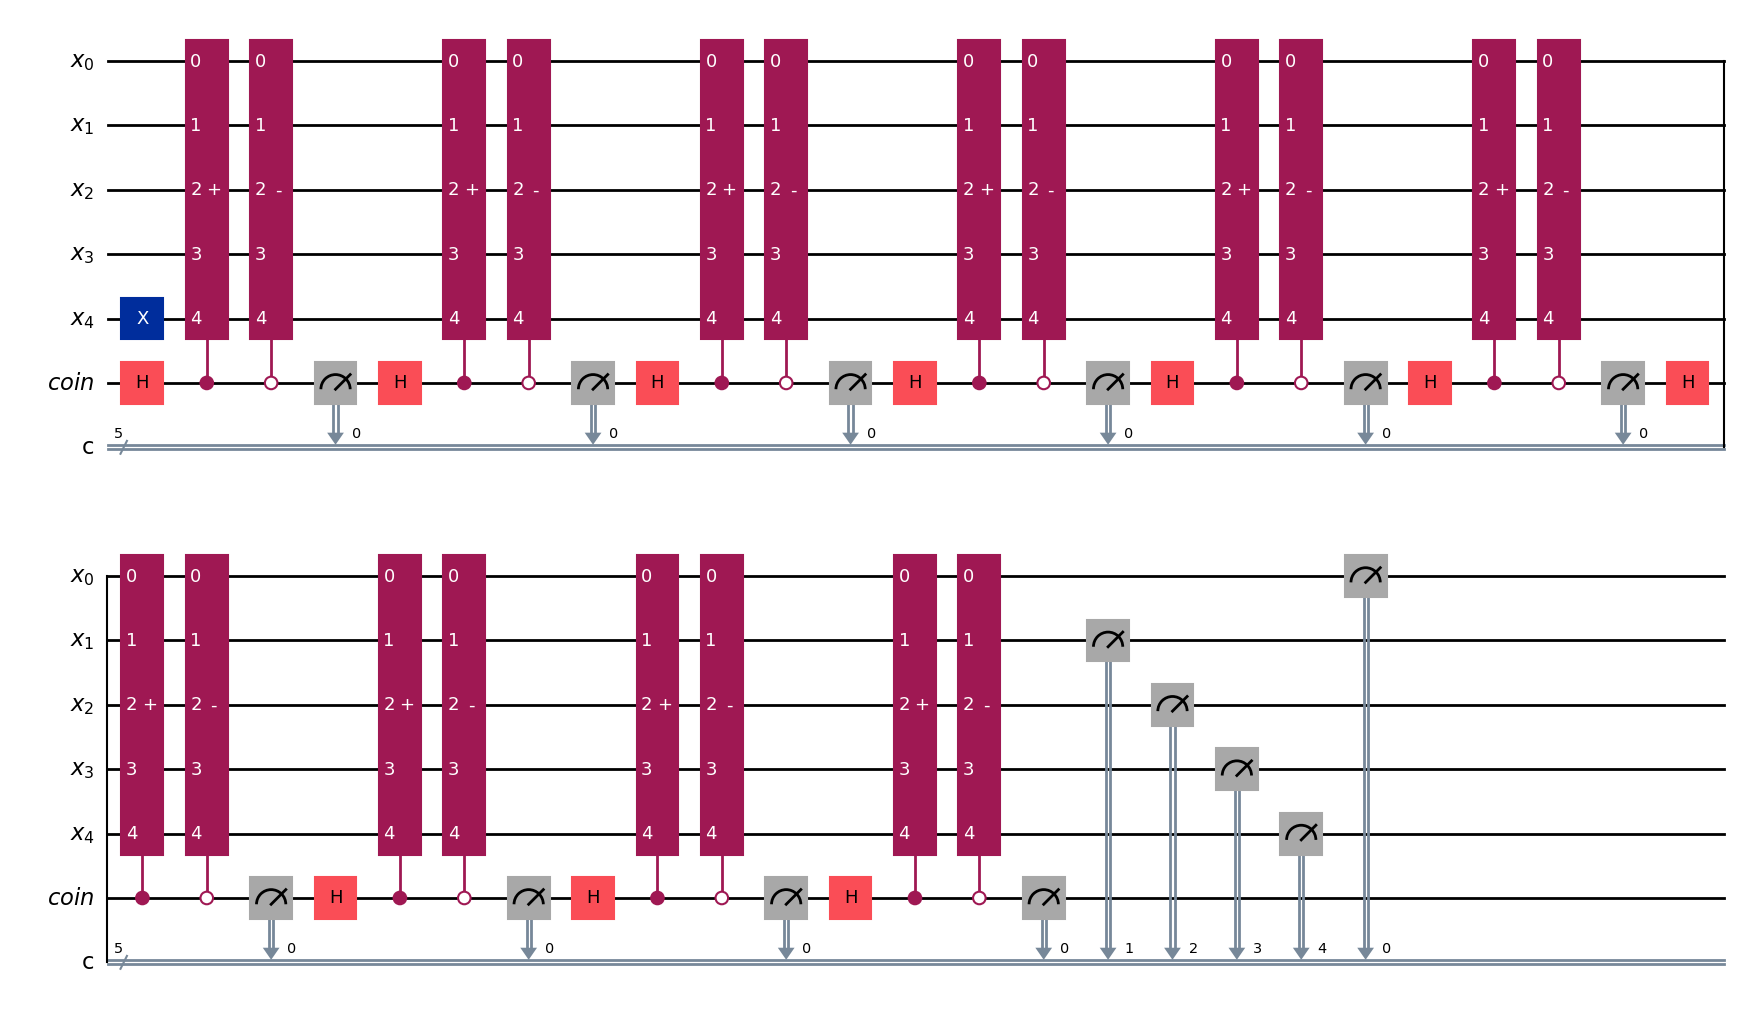

In [3]:
qubits = 5
t = 10
qr = QuantumRegister(qubits, 'x')
qa = QuantumRegister(1, 'coin')
c = ClassicalRegister(qubits, 'c')
qc = QuantumCircuit(qr,qa, c)

qc.x(qr[qubits-1])

for i in range(t):
    qc.h(qa)
    qc = qc.compose(increment_operator(qubits).control(1), [qa, *qr])
    qc = qc.compose(decrement_operator(qubits).control(1, ctrl_state='0'), [qa, *qr])
    qc.measure(qa, c[0])
qc.measure(qr, c)
qc.draw('mpl')

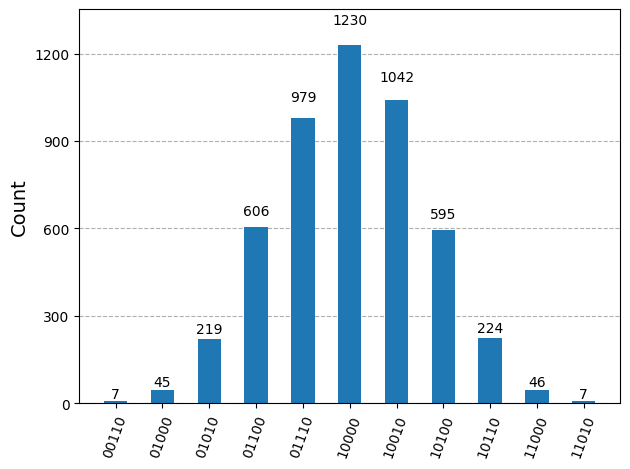

In [4]:
shots = 5000
counts = fq.run(qc, shots)

plot_histogram(counts)